# Métricas de clasificación en machine learning

Este notebook explica de forma práctica las métricas más importantes para evaluar modelos de **clasificación binaria**, incluyendo:

- Accuracy
- Precision
- Recall
- F1-score
- Matriz de confusión
- ROC-AUC
- PR-AUC
- Thresholds o puntos de corte

La idea no es solo ver fórmulas, sino entender **qué significa cada métrica**, **cuándo usarla** y **qué errores puede esconder**.

## 1. Importar librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    classification_report
)

## 2. Crear un dataset de ejemplo

Vamos a construir un dataset sintético de clasificación binaria.

- La clase **0** será “no evento”
- La clase **1** será “evento”

Por ejemplo, en riesgo crediticio la clase 1 podría ser **default**, en fraude podría ser **fraude**, y en medicina podría ser **paciente enfermo**.

In [2]:
X, y = make_classification(
    n_samples=5000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    n_clusters_per_class=2,
    weights=[0.85, 0.15],
    flip_y=0.02,
    class_sep=1.0,
    random_state=52
)

columns = [f'feature_{i}' for i in range(X.shape[1])]
X = pd.DataFrame(X, columns=columns)
y = pd.Series(y, name='target')

X.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9
0,2.624937,2.249558,2.702584,-1.793293,2.450204,1.050762,-6.656425,1.229970,-0.482763,0.620013
1,2.305142,3.421093,1.161978,-0.548234,1.639105,0.132616,-7.160948,-0.316894,-0.651038,0.491490
2,2.567272,1.698086,-1.387019,-0.131689,1.536307,0.848720,-4.463319,0.837160,2.255919,1.017023
3,-0.200908,-0.441874,-3.962137,-0.535840,0.132935,-0.222556,1.289288,0.833654,2.523293,1.107650
4,2.899509,-1.059774,-5.395641,-0.157245,-0.469053,1.320621,0.346802,1.831040,6.607547,-0.321399


In [3]:
y.value_counts(normalize=True)

target
0    0.842
1    0.158
Name: proportion, dtype: float64

Observa que este dataset está **desbalanceado**: la clase 1 ocurre mucho menos que la clase 0.

Esto es importante porque varias métricas se comportan distinto cuando hay desbalance.

## 3. Train / test split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=52
)

X_train.shape, X_test.shape

((3750, 10), (1250, 10))

## 4. Entrenar un modelo base

Usaremos una **regresión logística** porque es un modelo clásico, estable y fácil de interpretar.

In [5]:
num_cols = X.columns.tolist()

numeric_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocess = ColumnTransformer(transformers=[
    ('num', numeric_pipe, num_cols)
])

model = Pipeline(steps=[
    ('prep', preprocess),
    ('clf', LogisticRegression(max_iter=3000))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,t

In [6]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

pd.DataFrame({
    'real': y_test.head(10).values,
    'pred': y_pred[:10],
    'proba_clase_1': y_pred_proba[:10]
})

,real,pred,proba_clase_1
0,0,0,0.015553
1,0,0,0.193441
2,0,0,0.207571
3,0,0,0.024013
4,0,0,0.092031
5,0,0,0.090154
6,0,0,0.115892
7,0,0,0.236466
8,0,0,0.046173
9,0,0,0.173327


## 5. Matriz de confusión

La matriz de confusión es la base para entender casi todas las métricas de clasificación.

En clasificación binaria tenemos cuatro resultados posibles:

- **True Negative (TN):** predijo 0 y era 0
- **False Positive (FP):** predijo 1 pero era 0
- **False Negative (FN):** predijo 0 pero era 1
- **True Positive (TP):** predijo 1 y era 1

In [7]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[1035,   17],
       [ 188,   10]])

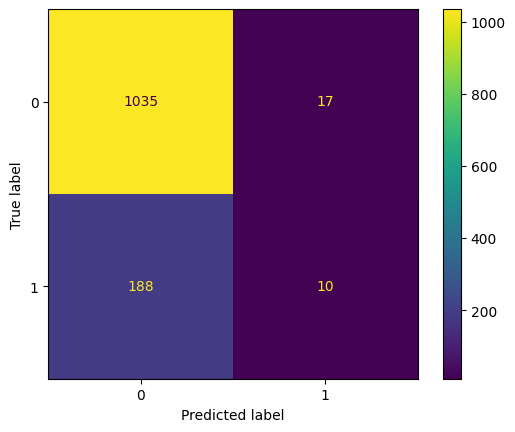

In [8]:
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

In [9]:
tn, fp, fn, tp = cm.ravel()

pd.DataFrame({
    'valor': [tn, fp, fn, tp]
}, index=['TN', 'FP', 'FN', 'TP'])

,valor
TN,1035
FP,17
FN,188
TP,10


## 6. Accuracy

### Idea

La **accuracy** mide el porcentaje total de predicciones correctas.

### Fórmula

Accuracy = (TP + TN) / (TP + TN + FP + FN)

### Intuición

Responde a la pregunta:

> “¿Qué proporción del total clasifiqué bien?”

### Problema

Puede ser engañosa cuando las clases están desbalanceadas.

In [10]:
acc = accuracy_score(y_test, y_pred)
acc

0.836

In [11]:
accuracy_manual = (tp + tn) / (tp + tn + fp + fn)
accuracy_manual

np.float64(0.836)

### Ejemplo de por qué puede fallar

Imagina un dataset donde 95% es clase 0 y 5% es clase 1.
Si un modelo predice siempre 0, tendría 95% de accuracy, pero sería inútil para encontrar la clase positiva.

In [12]:
y_dummy = np.array([0]*95 + [1]*5)
y_pred_dummy = np.array([0]*100)

accuracy_score(y_dummy, y_pred_dummy)

0.95

## 7. Precision

### Idea

La **precision** mide qué tan confiables son las predicciones positivas del modelo.

### Fórmula

Precision = TP / (TP + FP)

### Intuición

Responde a la pregunta:

> “De todo lo que predije como positivo, ¿cuánto realmente era positivo?”

### Cuándo importa mucho

Cuando el costo de un **falso positivo** es alto.

Ejemplos:
- marcar una transacción legítima como fraude
- rechazar a un buen cliente
- enviar muchos pacientes sanos a pruebas invasivas

In [13]:
prec = precision_score(y_test, y_pred)
prec

0.37037037037037035

In [14]:
precision_manual = tp / (tp + fp)
precision_manual

np.float64(0.37037037037037035)

## 8. Recall o sensibilidad

### Idea

El **recall** mide qué porcentaje de los positivos reales logró capturar el modelo.

### Fórmula

Recall = TP / (TP + FN)

### Intuición

Responde a la pregunta:

> “De todos los positivos reales, ¿cuántos encontré?”

### Cuándo importa mucho

Cuando el costo de un **falso negativo** es alto.

Ejemplos:
- no detectar un fraude
- no detectar una enfermedad
- no identificar un cliente que sí va a caer en default

In [15]:
rec = recall_score(y_test, y_pred)
rec

0.050505050505050504

In [16]:
recall_manual = tp / (tp + fn)
recall_manual

np.float64(0.050505050505050504)

## 9. F1-score

### Idea

El **F1-score** combina precision y recall en una sola métrica.

### Fórmula

F1 = 2 * (Precision * Recall) / (Precision + Recall)

### Intuición

Es útil cuando quieres un balance entre:
- no disparar demasiados falsos positivos
- no dejar escapar demasiados verdaderos positivos

### Importante

El F1-score será alto solo si **precision y recall** son ambos razonablemente altos.

In [17]:
f1 = f1_score(y_test, y_pred)
f1

0.08888888888888889

In [18]:
f1_manual = 2 * (prec * rec) / (prec + rec)
f1_manual

0.08888888888888889

## 10. Ver todas las métricas juntas

In [19]:
metrics_df = pd.DataFrame({
    'metric': ['accuracy', 'precision', 'recall', 'f1'],
    'value': [acc, prec, rec, f1]
})
metrics_df

,metric,value
0,accuracy,0.836000
1,precision,0.370370
2,recall,0.050505
3,f1,0.088889


In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.98      0.91      1052
           1       0.37      0.05      0.09       198

    accuracy                           0.84      1250
   macro avg       0.61      0.52      0.50      1250
weighted avg       0.77      0.84      0.78      1250



## 11. ¿Qué pasa si cambio el threshold?

Muchos modelos de clasificación no predicen directamente una clase, sino una **probabilidad**.

Luego convertimos esa probabilidad en clase usando un umbral, normalmente **0.50**.

Pero ese threshold se puede mover.

- Threshold más bajo → predices más positivos → sube recall, puede bajar precision
- Threshold más alto → predices menos positivos → sube precision, puede bajar recall

In [21]:
def evaluate_threshold(y_true, y_score, threshold):
    y_pred_thr = (y_score >= threshold).astype(int)
    return {
        'threshold': threshold,
        'accuracy': accuracy_score(y_true, y_pred_thr),
        'precision': precision_score(y_true, y_pred_thr, zero_division=0),
        'recall': recall_score(y_true, y_pred_thr, zero_division=0),
        'f1': f1_score(y_true, y_pred_thr, zero_division=0)
    }

In [22]:
threshold_results = pd.DataFrame([
    evaluate_threshold(y_test, y_pred_proba, thr)
    for thr in [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]
])

threshold_results

,threshold,accuracy,precision,recall,f1
0,0.2,0.7584,0.360215,0.676768,0.470175
1,0.3,0.8040,0.365714,0.323232,0.343164
2,0.4,0.8224,0.342105,0.131313,0.189781
3,0.5,0.8360,0.370370,0.050505,0.088889
4,0.6,0.8392,0.285714,0.010101,0.019512
5,0.7,0.8424,0.666667,0.010101,0.019900
6,0.8,0.8408,0.000000,0.000000,0.000000


Acá se ve claramente que las métricas cambian aunque el modelo sea el mismo. Lo único que cambió fue el punto de corte.

## 12. ROC curve

La curva ROC evalúa el comportamiento del modelo a través de **todos los thresholds posibles**.

En el eje Y se grafica:
- **TPR** = True Positive Rate = Recall

En el eje X se grafica:
- **FPR** = False Positive Rate = FP / (FP + TN)

La idea es ver qué tanto recall conseguimos sin disparar demasiado el falso positivo.

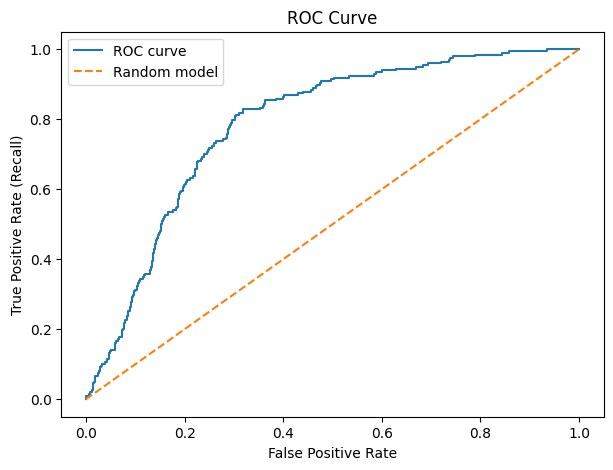

In [23]:
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label='ROC curve')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend()
plt.show()

## 13. AUC

### ¿Qué es AUC?

**AUC** significa **Area Under the Curve**, normalmente refiriéndose al área bajo la curva ROC.

### Intuición más importante

El ROC-AUC mide la capacidad del modelo para **ordenar correctamente** los casos:

- asignar score más alto a positivos reales
- asignar score más bajo a negativos reales

### Interpretación rápida

- **0.50**: el modelo no discrimina, parecido a adivinar
- **0.60 - 0.70**: discriminación débil
- **0.70 - 0.80**: razonable
- **0.80 - 0.90**: buena
- **> 0.90**: muy buena

Esto no es una ley universal, pero sirve como guía inicial.

### Ventaja

AUC no depende de un único threshold. Evalúa el ranking completo de scores.

In [24]:
auc = roc_auc_score(y_test, y_pred_proba)
auc

0.7857280024580404

### ¿Por qué AUC suele ser tan usado?

Porque en muchos problemas el objetivo inicial no es fijar de inmediato un threshold, sino medir si el modelo **separa bien** buenos y malos casos.

Por eso en riesgo crediticio, fraude o marketing, AUC suele ser una métrica estándar de discriminación.

## 14. Limitaciones del AUC

Aunque AUC es muy útil, no responde todo.

### Limitaciones importantes

1. **No te dice qué pasa en un threshold específico**
2. **No refleja directamente el costo de negocio**
3. **Puede verse bien incluso si precision en la clase positiva no es tan buena**
4. En datasets muy desbalanceados, a veces conviene revisar también **PR-AUC**

## 15. Precision-Recall curve y PR-AUC

Cuando la clase positiva es rara, muchas veces interesa más enfocarse en:

- cuántos positivos reales capturo (**recall**)
- cuántos de mis positivos predichos sí eran correctos (**precision**)

Para eso sirve mucho la curva **Precision-Recall**.

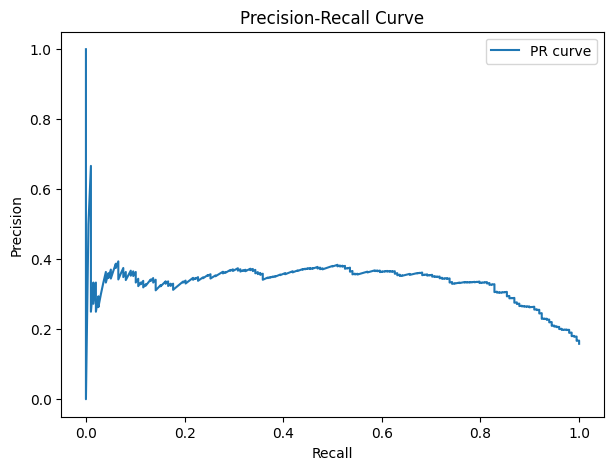

0.3382821607788038

In [25]:
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, y_pred_proba)
ap = average_precision_score(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(recall_vals, precision_vals, label='PR curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

ap

### Average Precision / PR-AUC

La métrica `average_precision_score` resume el desempeño de la curva Precision-Recall.

En problemas de fuerte desbalance, esta métrica puede ser más informativa que ROC-AUC.

## 16. Comparación resumida de métricas

In [26]:
summary = pd.DataFrame({
    'metrica': ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC'],
    'valor': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_pred_proba),
        average_precision_score(y_test, y_pred_proba)
    ]
}).round(4)

summary

,metrica,valor
0,Accuracy,0.8360
1,Precision,0.3704
2,Recall,0.0505
3,F1,0.0889
4,ROC-AUC,0.7857
5,PR-AUC,0.3383


## 17. ¿Cuándo usar cada métrica?

### Accuracy
Úsala con cuidado. Sirve más cuando las clases están relativamente balanceadas y el costo de los errores es parecido.

### Precision
Úsala cuando te preocupa mucho el falso positivo.

### Recall
Úsala cuando te preocupa mucho el falso negativo.

### F1-score
Úsala cuando necesitas balancear precision y recall.

### ROC-AUC
Úsala para medir capacidad de discriminación global o ranking del modelo.

### PR-AUC
Úsala especialmente cuando la clase positiva es rara y te importa el desempeño sobre esa clase.

## 18. Ejemplo de interpretación de negocio

### Riesgo de crédito

- **Recall alto**: capturas más clientes riesgosos
- **Precision alta**: cuando dices que alguien es riesgoso, normalmente sí lo es
- **AUC alto**: el score ordena bien clientes más riesgosos vs menos riesgosos

### Fraude

- A menudo interesa mucho **recall**, porque dejar pasar fraude cuesta mucho
- Pero también importa **precision**, porque demasiadas alertas falsas dañan la operación

### Medicina

- En screening suele priorizarse **recall**
- En pruebas costosas o invasivas puede cobrar más peso la **precision**

## 19. Conclusiones

Ideas clave:

1. No existe una única métrica “mejor” para todos los casos.
2. Accuracy sola puede ser engañosa.
3. Precision y recall dependen del costo de negocio de FP y FN.
4. F1 resume el balance entre precision y recall.
5. ROC-AUC mide discriminación global del modelo.
6. En desbalance fuerte, revisa también PR-AUC.
7. Elegir el threshold correcto es parte del problema de negocio, no solo del modelado.

## 20. Ejercicio sugerido

Prueba estas modificaciones:

- cambia el desbalance del dataset en `make_classification`
- cambia el threshold a 0.25, 0.35, 0.65, etc.
- compara cómo cambian precision, recall y F1
- entrena otro modelo y compara su ROC-AUC y PR-AUC